## Project Overview
The goal of this project is to predict whether a data scientist will remain a member 
of the United Data Scientists Union (UDSU) based on a dataset of 2,000 current and 
former members.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

## Read and analyze the data from the CSV file

In [2]:
df = pd.read_csv('Ben-Custom_Dataset.csv')

print("=== Shape ===")
print(df.shape)

print("\n=== First 5 rows ===")
display(df.head())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Basic Stats ===")
display(df.describe(include='all'))

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Column Value Counts ===")
print(df['LeftUnion'].value_counts())

=== Shape ===
(2000, 21)

=== First 5 rows ===


,ID,gender,Management,USAcitizen,Married,MonthsInUnion,ContinuingEd,StateOfResidence,Connectivity,FeatureA,...,FeatureC,FeatureD,FeatureE,FeatureF,DuesFrequency,PaperlessBilling,PaymentMethod,MonthlyDues,TotalDues,LeftUnion
0,Ben1-17038,Male,0,No,No,22,Yes,IL,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.75,2095,Yes
1,Ben2-16712,Male,1,No,No,35,Yes,IL,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,3474.05,Yes
2,Ben3-13393,Male,1,No,No,66,Yes,IL,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),110.90,7432.05,Yes
3,Ben4-17430,Male,0,Yes,Yes,15,Yes,MO,No,Maryville,...,Maryville,Maryville,Maryville,Maryville,Two year,No,Mailed check,19.35,278.85,No
4,Ben5-16513,Male,0,No,No,2,Yes,IL,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),73.25,131.05,Yes



=== Data Types ===
ID                   object
gender               object
Management            int64
USAcitizen           object
Married              object
MonthsInUnion         int64
ContinuingEd         object
StateOfResidence     object
Connectivity         object
FeatureA             object
FeatureB             object
FeatureC             object
FeatureD             object
FeatureE             object
FeatureF             object
DuesFrequency        object
PaperlessBilling     object
PaymentMethod        object
MonthlyDues         float64
TotalDues            object
LeftUnion            object
dtype: object

=== Basic Stats ===


,ID,gender,Management,USAcitizen,Married,MonthsInUnion,ContinuingEd,StateOfResidence,Connectivity,FeatureA,...,FeatureC,FeatureD,FeatureE,FeatureF,DuesFrequency,PaperlessBilling,PaymentMethod,MonthlyDues,TotalDues,LeftUnion
count,2000,2000,2000.000000,2000,2000,2000.000000,2000,2000,2000,2000,...,2000,2000,2000,2000,2000,2000,2000,2000.000000,2000,2000
unique,2000,2,NaN,2,2,NaN,2,2,3,3,...,3,3,3,3,3,2,4,NaN,1951,2
top,Ben1984-18316,Male,NaN,No,No,NaN,Yes,MO,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,19.75,No
freq,1,1006,NaN,1074,1432,NaN,1827,1142,856,995,...,859,972,769,775,1086,1189,676,NaN,4,1487
mean,NaN,NaN,0.159000,NaN,NaN,45.046000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.868100,NaN,NaN
std,NaN,NaN,0.365768,NaN,NaN,100.866302,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.365005,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.800000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.237500,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.875000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.562500,NaN,NaN



=== Missing Values ===
ID                  0
gender              0
Management          0
USAcitizen          0
Married             0
MonthsInUnion       0
ContinuingEd        0
StateOfResidence    0
Connectivity        0
FeatureA            0
FeatureB            0
FeatureC            0
FeatureD            0
FeatureE            0
FeatureF            0
DuesFrequency       0
PaperlessBilling    0
PaymentMethod       0
MonthlyDues         0
TotalDues           0
LeftUnion           0
dtype: int64

=== Target Column Value Counts ===
LeftUnion
No     1487
Yes     513
Name: count, dtype: int64


## Helper functions to clean the data and remove bad rows

In [3]:
def find_and_remove_bad_rows(df):

    # Step 1: Remove rows with null values
    df_clean = df.dropna()
    print(f"Rows removed due to nulls: {len(df) - len(df_clean)}")

    # Step 2: Remove rows with whitespace-only values
    bad_row_indices = set()
    for col in df_clean.columns:
        if df_clean[col].dtype == 'object':
            is_whitespace = df_clean[col].str.strip() == ''
            bad_row_indices.update(df_clean[is_whitespace].index)

    print(f"Rows removed due to whitespace: {len(bad_row_indices)}")
    df_clean = df_clean.drop(index=bad_row_indices).reset_index(drop=True)

    print(f"\nRows before cleaning: {len(df)}")
    print(f"Rows after cleaning:  {len(df_clean)}")
    return df_clean

In [4]:
def remove_unexpected_values(df, feature_cols, valid_values):
    df_clean = df.copy()
    before = len(df_clean)

    bad_row_indices = set()
    for col in feature_cols:
        is_valid = df_clean[col].isin(valid_values)
        unexpected = df_clean[is_valid == False]
        bad_row_indices.update(unexpected.index)

    df_clean = df_clean.drop(index=bad_row_indices).reset_index(drop=True)
    print(f"Rows removed due to unexpected values: {before - len(df_clean)}")
    print(f"Rows remaining: {len(df_clean)}")
    return df_clean

In [5]:
def remove_numeric_outliers(df, numeric_cols):
    df_clean = df.copy()

    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        is_within_bounds = df_clean[col].between(lower_bound, upper_bound)
        rows_removed = len(df_clean) - is_within_bounds.sum()

        print(f"{col}: removed {rows_removed} outlier rows (bounds: {lower_bound:.2f} to {upper_bound:.2f})")

        df_clean = df_clean[is_within_bounds]

    df_clean = df_clean.reset_index(drop=True)
    print(f"\nTotal rows remaining: {len(df_clean)}")
    return df_clean

## Data Preparation

Steps performed:

### 1.  Remove the ID column  
It is a unique identifier with no meaning.
### 2.  Remove rows with bad data  
Checks for null values and whitespace-only values.
### 3.  Remove unexpected values  
FeatureA through FeatureF contained values other than the expected "Yes" or "No".  I removed 469 rows that contained the value "Maryville", which is probably meant to simulate corrupted data.
### 4.  Remove outliers  
Used the IQR method to remove outlier values in the numeric columns that were skewing my graphs.  The most significant outlier 
found was a MonthsInUnion value of 999 (over 83 years).  After outlier removal 1,500 rows remained.
### 5.  Encoding  
I encoded the categorical columns with binary values (Yes/No or Male/Female) to 0/1 by using LabelEncoder.  I used pandas get_dummies() to encode multi-category columns.
### 6.  Normalization  
I normalized the three numeric columns using StandardScaler.  This was necessary so the TotalDues column wouldn't outweigh MonthsInUnion in importance.

In [6]:
df_clean = df.copy()

# --- Drop ID column ---
df_clean.drop(columns=['ID'], inplace=True)

# --- Remove bad rows ---
df_clean = find_and_remove_bad_rows(df_clean)

# --- Remove rows with unexpected values in FeatureA-F ---
feature_cols = ['FeatureA', 'FeatureB', 'FeatureC', 'FeatureD', 'FeatureE', 'FeatureF']
valid_values = ['Yes', 'No']
df_clean = remove_unexpected_values(df_clean, feature_cols, valid_values)

# --- Convert TotalDues to numeric ---
df_clean['TotalDues'] = df_clean['TotalDues'].astype(float)

# --- Remove outliers ---
numeric_cols = ['MonthsInUnion', 'MonthlyDues', 'TotalDues']
df_clean = remove_numeric_outliers(df_clean, numeric_cols)

# --- Encode binary columns ---
le = LabelEncoder()
binary_cols = [
    'gender', 'USAcitizen', 'Married', 'ContinuingEd',
    'FeatureA', 'FeatureB', 'FeatureC', 'FeatureD', 'FeatureE', 'FeatureF',
    'PaperlessBilling'
]
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# --- Encode multi-category columns ---
df_clean = pd.get_dummies(df_clean, columns=['Connectivity', 'StateOfResidence',
                                              'DuesFrequency', 'PaymentMethod'], dtype=int)

# --- Copy dataframe to use for plots before normalizing features and encoding target ---
df_for_plots = df_clean.copy()

# --- Encode target column ---
df_clean['LeftUnion'] = df_clean['LeftUnion'].map({'Yes': 1, 'No': 0})
print("\nTarget: 1 = Left union, 0 = Stayed")

# --- Normalize numeric columns ---
scaler = StandardScaler()
df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

print("\n=== Cleaned dataset shape:", df_clean.shape, "===")
display(df_clean.head())

Rows removed due to nulls: 0
Rows removed due to whitespace: 3

Rows before cleaning: 2000
Rows after cleaning:  1997
Rows removed due to unexpected values: 469
Rows remaining: 1528
MonthsInUnion: removed 28 outlier rows (bounds: -64.50 to 131.50)
MonthlyDues: removed 0 outlier rows (bounds: 9.13 to 145.58)
TotalDues: removed 0 outlier rows (bounds: -5586.01 to 10797.04)

Total rows remaining: 1500

Target: 1 = Left union, 0 = Stayed

=== Cleaned dataset shape: (1500, 27) ===


,gender,Management,USAcitizen,Married,MonthsInUnion,ContinuingEd,FeatureA,FeatureB,FeatureC,FeatureD,...,Connectivity_Fiber optic,StateOfResidence_IL,StateOfResidence_MO,DuesFrequency_Month-to-month,DuesFrequency_One year,DuesFrequency_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,0,0,-0.435728,1,1,0,0,0,...,1,1,0,1,0,0,0,0,1,0
1,1,1,0,0,0.088921,1,0,0,0,0,...,1,1,0,1,0,0,0,0,1,0
2,1,1,0,0,1.340007,1,0,1,1,1,...,1,1,0,0,1,0,0,1,0,0
3,1,0,0,0,-1.242880,1,0,0,0,0,...,1,1,0,1,0,0,0,1,0,0
4,1,0,1,1,-1.081450,1,0,1,1,0,...,0,0,1,1,0,0,0,0,0,1


## Plots

I created four charts to visualize the data.

### 1.  Violin Plot  
The violin plot showed that members who left the union (Yes) were concentrated in the lower ranges of MonthsInUnion and TotalDues.  Members who stayed were more widely distributed and had more values near the top of the range for those columns.  This suggests that tenure in the union has a strong influence on whether a member remains.  The MonthlyDues column was not a strong predictor.

### 2.  Scree Plot  
The scree plot of principle components showed a steep drop in variance after the first two components.  That means a small number of features cause most of the variance in the data.

### 3.  Scatter Plot  
The scatter plot showed the linear relationship between MonthlyDues and TotalDues.  Members who pay more per month have higher total dues.  Members who leave the union are mostly in the lower TotalDues range.  That is consistent with the Violin Plot, which showed that new members leave the union more often.

### 4.  Bivariate Plots  
These plots also showed the relationship between the three numeric columns.  The graphs on the left clearly show that newer members who have paid less leave the union more often.

count    1500.000000
mean       32.796667
std        24.786735
min         1.000000
25%         9.000000
50%        29.500000
75%        56.000000
max        72.000000
Name: MonthsInUnion, dtype: float64


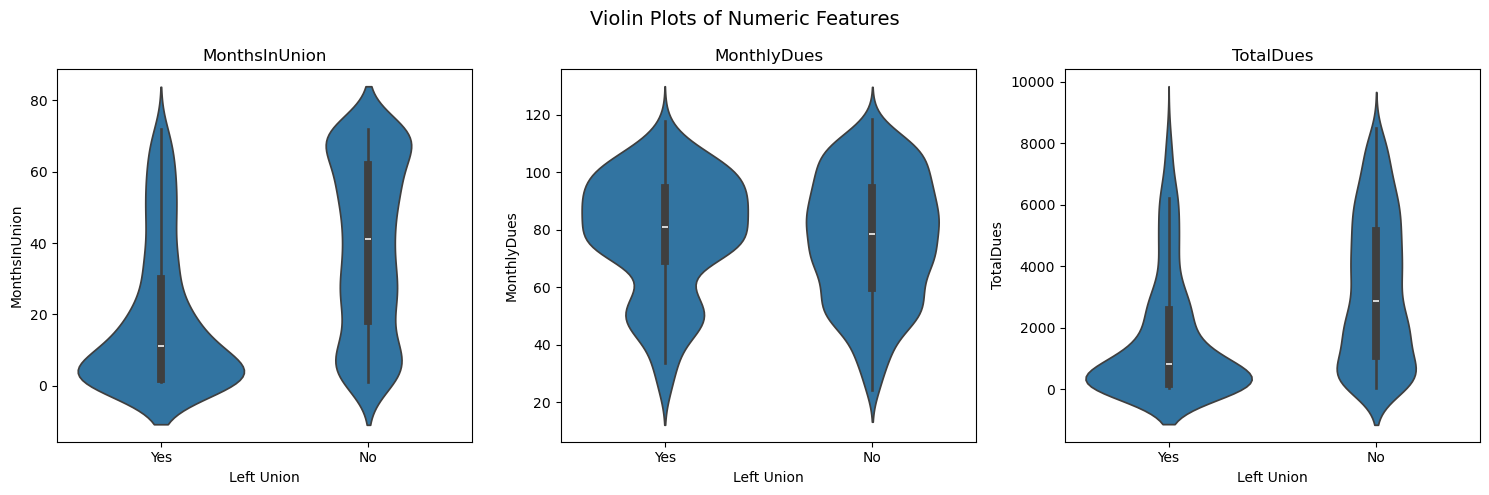

In [7]:
print(df_for_plots['MonthsInUnion'].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Violin Plots of Numeric Features', fontsize=14)

for i, col in enumerate(['MonthsInUnion', 'MonthlyDues', 'TotalDues']):
    sns.violinplot(data=df_for_plots, x='LeftUnion', y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Left Union')

plt.tight_layout()
plt.show()

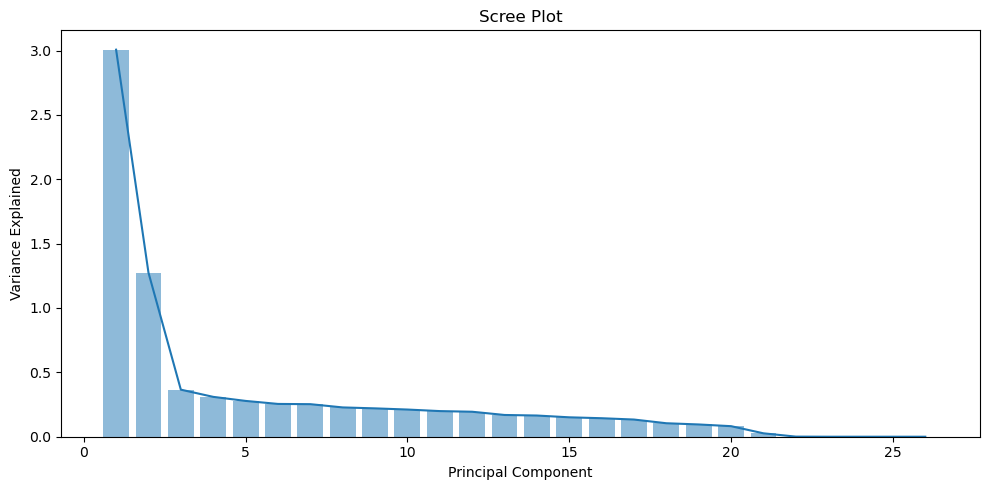

In [8]:
X_for_pca = df_clean.drop(columns=['LeftUnion'])

pca = PCA()
pca.fit(X_for_pca)

Y_for_pca = range(1, len(pca.explained_variance_) + 1)

plt.figure(figsize=(10, 5))
plt.plot(Y_for_pca, pca.explained_variance_)
plt.bar(Y_for_pca, pca.explained_variance_, alpha=0.5)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot')
plt.tight_layout()
plt.show()

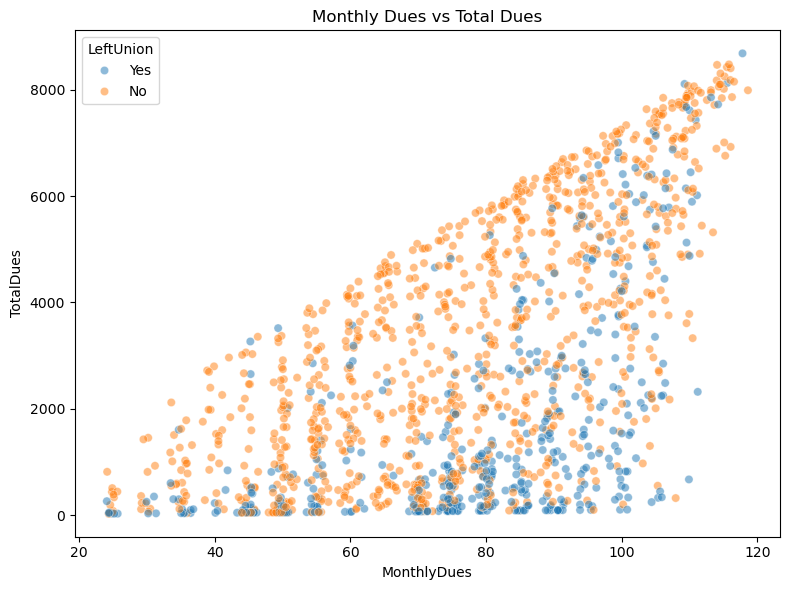

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_for_plots,
    x='MonthlyDues',
    y='TotalDues',
    hue='LeftUnion',
    alpha=0.5
)
plt.title('Monthly Dues vs Total Dues')
plt.tight_layout()
plt.show()

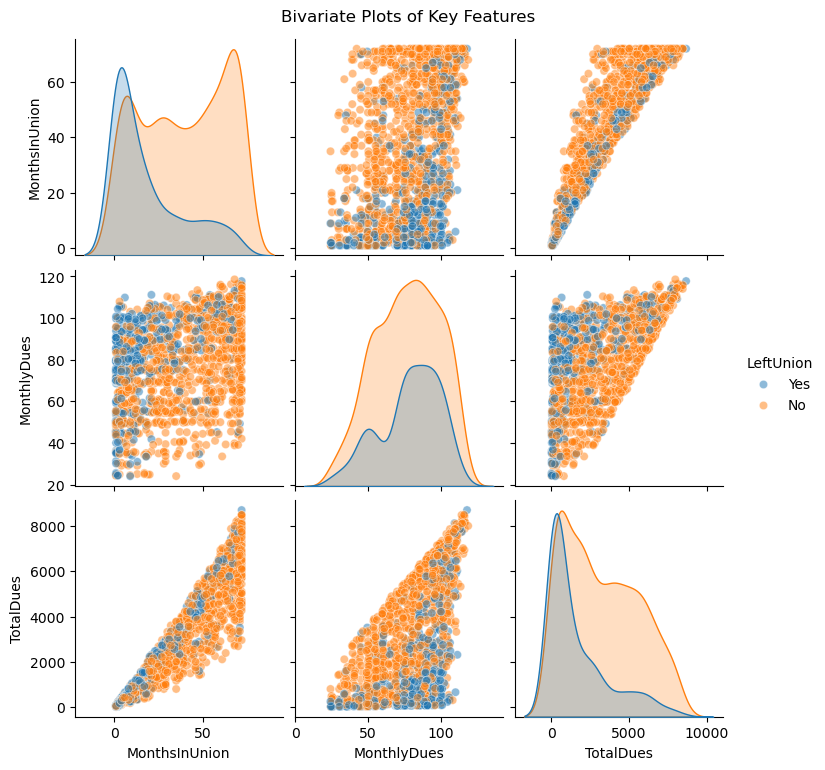

In [10]:
key_features = ['MonthsInUnion', 'MonthlyDues', 'TotalDues', 'LeftUnion']

sns.pairplot(
    df_for_plots[key_features],
    hue='LeftUnion',
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)
plt.suptitle('Bivariate Plots of Key Features', y=1.02)
plt.show()

## Train Test Split

In [11]:
X = df_clean.drop(columns=['LeftUnion'])
y = df_clean['LeftUnion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Target balance (train):\n{y_train.value_counts(normalize=True).round(3)}")

Train: 1125 rows | Test: 375 rows
Target balance (train):
LeftUnion
0    0.681
1    0.319
Name: proportion, dtype: float64


## Logistic Regression

In [12]:
def train_logistic_regression(X_train, X_test, y_train, y_test):
    model = LogisticRegression()
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train) * 100
    test_score  = model.score(X_test, y_test) * 100

    print(f"Logistic Regression — Train: {train_score:.2f}%  Test: {test_score:.2f}%")
    return model, train_score, test_score

## Linear Regression 
Liniear Regression is a bad choice because it predicts continuous values and this is a classification problem.  I'll keep the results here for comparison anyways.

In [13]:
def train_linear_regression(X_train, X_test, y_train, y_test):
    model = LinearRegression()
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train) * 100
    test_score  = model.score(X_test, y_test) * 100

    print(f"Linear Regression — Train: {train_score:.2f}%  Test: {test_score:.2f}%")
    return model, train_score, test_score

## Decision Tree

In [14]:
def train_decision_tree(X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train) * 100
    test_score  = model.score(X_test, y_test) * 100

    print(f"Decision Tree — Train: {train_score:.2f}%  Test: {test_score:.2f}%")
    return model, train_score, test_score

## Neural Network

In [15]:
def train_neural_network(X_train, X_test, y_train, y_test):
    model = MLPClassifier(hidden_layer_sizes=(8, 4), random_state=42, max_iter=5000)
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train) * 100
    test_score  = model.score(X_test, y_test) * 100

    print(f"Neural Network — Train: {train_score:.2f}%  Test: {test_score:.2f}%")
    return model, train_score, test_score

## Random Forest

In [16]:
def train_random_forest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train) * 100
    test_score  = model.score(X_test, y_test) * 100

    print(f"Random Forest — Train: {train_score:.2f}%  Test: {test_score:.2f}%")
    return model, train_score, test_score

## Train the models and display the results

In [17]:
model_lg, train_lg, test_lg = train_logistic_regression(X_train, X_test, y_train, y_test)
model_lr, train_lr, test_lr = train_linear_regression(X_train, X_test, y_train, y_test)
model_dt, train_dt, test_dt = train_decision_tree(X_train, X_test, y_train, y_test)
model_rf, train_rf, test_rf = train_random_forest(X_train, X_test, y_train, y_test)
model_nn, train_nn, test_nn = train_neural_network(X_train, X_test, y_train, y_test)

Logistic Regression — Train: 77.42%  Test: 77.07%
Linear Regression — Train: 24.05%  Test: 27.32%
Decision Tree — Train: 100.00%  Test: 71.47%
Random Forest — Train: 100.00%  Test: 73.60%
Neural Network — Train: 81.42%  Test: 75.47%


In [18]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear Regression', 'Decision Tree', 'Random Forest', 'Neural Network'],
    'TrainScore': [train_lg, train_lr, train_dt, train_rf, train_nn],
    'TestScore':  [test_lg,  test_lr, test_dt,  test_rf,  test_nn]
})

results = results.sort_values('TestScore', ascending=False).reset_index(drop=True)
display(results.round(2))

,Model,TrainScore,TestScore
0,Logistic Regression,77.42,77.07
1,Neural Network,81.42,75.47
2,Random Forest,100.00,73.60
3,Decision Tree,100.00,71.47
4,Linear Regression,24.05,27.32


## Results
The Logistic Regression model got the best score of 77.07.  Its TrainScore and TestScores were very similar, showing that the training data generalized well to the test data without overfitting.

The Decision Tree and Random Forest both got perfect 100% training scores, indicating they were overfitted as expected for those types of models.  The Random Forest did a bit better with a test score of 73.6%, compared to the Decision Tree's 71.47%.

The Neural Network was another strong performer.  It got a good test score of 75.47%.  It did not have the same overfitting problem as the tree models.  Its train score was only a bit higher than its test score.

Linear Regression is not a good model to use for this type of classification problem.  It only scored a 27.32%.


## Comparing my results to an educated guess

I expected that members who were paying higher monthly dues would be more likely to leave the union.  I thought rising costs would drive them away.  The members who paid lower dues were getting a better deal, so I thought they were be more likely to stay. However, the plots showed that MonthsInUnion was a stronger indicator than MonthlyDues.  Newer members were more likely to leave regardless of how much they were paying.

## How to improve

The Decision Tree and Random Forest models suffered from overfitting.  I think limiting the max_depth of the trees could prevent too much overfitting and improve their scores.

I used Principle Component Analysis to show the Scree Plot but I didn't use it before training the models.  If I had more time, I could have applied PCA as a preprocessing step to reduce the number of features.  There were many columns that did not account for much variance in the results.  Applying PCA could have reduced noise in the data and probably improved my results.  I think the Decision Tree and Random Forest models were probably most impacted by having too many redudant features, since they had an overfitting problem.